In [122]:
### Task 1: Construct Decision Tree models for classification and regression applications
#*Suggested Datasets: Pima Indians Diabetes Dataset (Classification) / Boston Housing Dataset (Regression)*


In [123]:
import warnings

In [124]:
warnings.filterwarnings("ignore")

In [125]:
import pandas as pd


In [126]:
from sklearn.model_selection import train_test_split

In [127]:
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"


In [128]:
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [129]:
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)


In [130]:
X_pima = pima_df[pima_cols[:-1]]


In [131]:
y_pima = pima_df['Outcome']


In [132]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_pima, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)


In [133]:
print("Pima Classification Training Set Shape:", X_train_c.shape)


Pima Classification Training Set Shape: (614, 8)


In [134]:
print("Pima Classification Test Set Shape:", X_test_c.shape)


Pima Classification Test Set Shape: (154, 8)


In [135]:
from sklearn.tree import DecisionTreeClassifier


In [136]:
from sklearn.metrics import accuracy_score, classification_report


In [137]:
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)


In [138]:
tree_clf.fit(X_train_c, y_train_c)


DecisionTreeClassifier(max_depth=4, random_state=42)

In [139]:
clf_preds = tree_clf.predict(X_test_c)


In [140]:
print(f"Decision Tree Classifier Test Accuracy: {accuracy_score(y_test_c, clf_preds) * 100:.2f}%\n")


Decision Tree Classifier Test Accuracy: 79.87%



In [141]:
print("--- Classification Report ---")


--- Classification Report ---


In [142]:
print(classification_report(y_test_c, clf_preds, target_names=['No Diabetes (0)', 'Diabetes (1)']))


                 precision    recall  f1-score   support

No Diabetes (0)       0.82      0.88      0.85       100
   Diabetes (1)       0.74      0.65      0.69        54

       accuracy                           0.80       154
      macro avg       0.78      0.76      0.77       154
   weighted avg       0.80      0.80      0.80       154



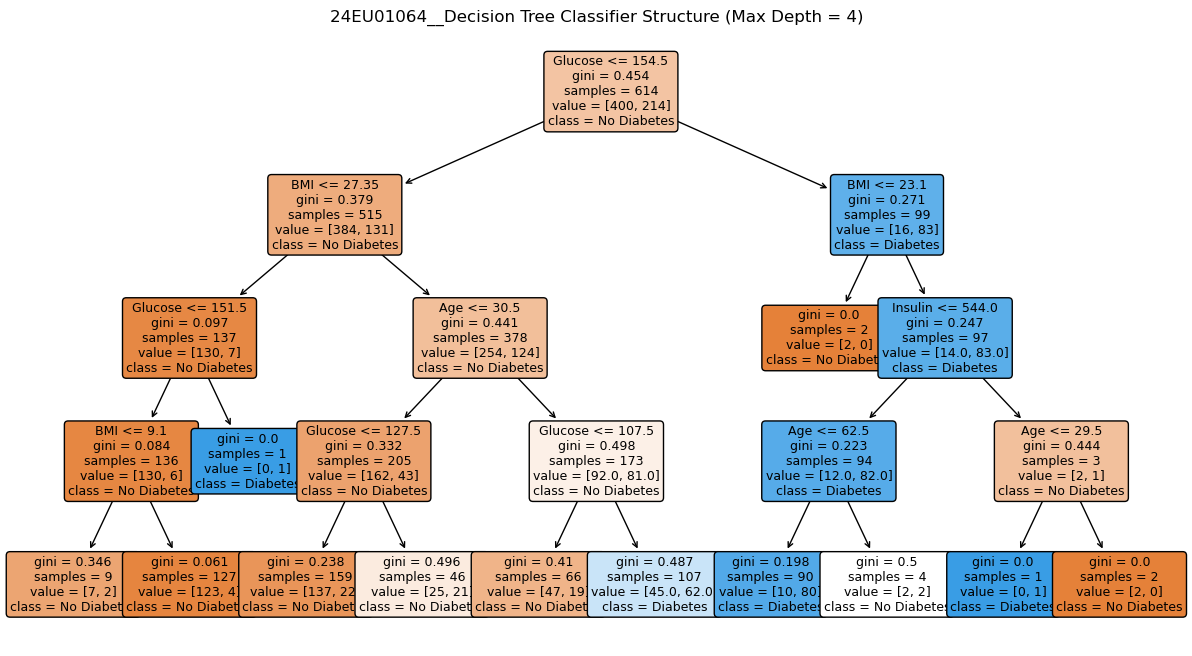

In [143]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(15, 8))
plot_tree(
    tree_clf, 
    feature_names=pima_cols[:-1], 
    class_names=['No Diabetes', 'Diabetes'], 
    filled=True, 
    rounded=True, 
    fontsize=9
)
plt.title("24EU01064__Decision Tree Classifier Structure (Max Depth = 4)")
plt.show()

In [144]:
from sklearn.tree import DecisionTreeRegressor


In [145]:
from sklearn.preprocessing import StandardScaler


In [146]:
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"


In [147]:
boston_df = pd.read_csv(boston_url)


In [148]:
boston_features = [col for col in boston_df.columns if col != 'medv']


In [149]:
X_boston = boston_df[boston_features]


In [150]:
y_boston = boston_df['medv']


In [151]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_boston, y_boston, test_size=0.20, random_state=42)


In [152]:
scaler_r = StandardScaler()


In [153]:
X_train_r_scaled = scaler_r.fit_transform(X_train_r)


In [154]:
X_test_r_scaled = scaler_r.transform(X_test_r)


In [155]:
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)


In [156]:
tree_reg.fit(X_train_r_scaled, y_train_r)


DecisionTreeRegressor(max_depth=5, random_state=42)

In [157]:
print("Decision Tree Regressor trained successfully. Max Depth set to 5.")


Decision Tree Regressor trained successfully. Max Depth set to 5.


In [158]:
from sklearn.metrics import mean_squared_error, r2_score


In [159]:
import numpy as np


In [160]:
reg_preds = tree_reg.predict(X_test_r_scaled)


In [161]:
mse_val = mean_squared_error(y_test_r, reg_preds)


In [162]:
rmse_val = np.sqrt(mse_val)


In [163]:
r2_val = r2_score(y_test_r, reg_preds)


In [164]:
print(f"Mean Squared Error (MSE): {mse_val:.4f}")


Mean Squared Error (MSE): 8.5539


In [165]:
print(f"Root Mean Squared Error (RMSE): {rmse_val:.4f} ($1000s)")


Root Mean Squared Error (RMSE): 2.9247 ($1000s)


In [166]:
print(f"R2 Coefficient of Determination: {r2_val:.4f}\n")


R2 Coefficient of Determination: 0.8834



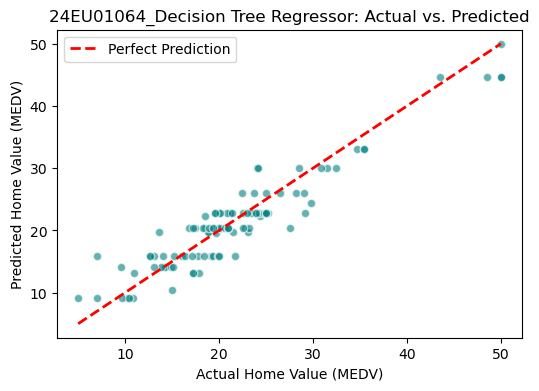

In [167]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test_r, reg_preds, color='teal', alpha=0.6, edgecolor='white')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title("24EU01064_Decision Tree Regressor: Actual vs. Predicted")
plt.xlabel("Actual Home Value (MEDV)")
plt.ylabel("Predicted Home Value (MEDV)")
plt.legend()
plt.show()



In [168]:
#Task 2: Develop ensemble learning models using Bagging, Random Forest, and Voting techniques

In [169]:
import warnings


In [170]:
warnings.filterwarnings("ignore")


In [171]:
import pandas as pd


In [172]:
from sklearn.model_selection import train_test_split


In [173]:
from sklearn.preprocessing import StandardScaler


In [174]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"


In [175]:
sonar_features = [f"F_{i}" for i in range(1, 61)]


In [176]:
sonar_columns = sonar_features + ['Class']


In [177]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)


In [178]:
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})


In [179]:
X_sonar = sonar_df[sonar_features]


In [180]:
y_sonar = sonar_df['Class_numeric']


In [181]:
scaler_sonar = StandardScaler()


In [182]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)


In [183]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

In [184]:
print("24EU01064")

24EU01064


In [185]:
print("Sonar Training Set Shape:", X_train_s.shape)


Sonar Training Set Shape: (145, 60)


In [186]:
print("Sonar Test Set Shape:", X_test_s.shape)


Sonar Test Set Shape: (63, 60)


In [187]:
from sklearn.ensemble import BaggingClassifier


In [188]:
from sklearn.metrics import accuracy_score


In [189]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
bagging_model.fit(X_train_s, y_train_s)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=50, n_jobs=-1, random_state=42)

In [190]:
bagging_preds = bagging_model.predict(X_test_s)


In [191]:
bagging_accuracy = accuracy_score(y_test_s, bagging_preds)


In [192]:
print(f"Bagging Classifier Test Accuracy: {bagging_accuracy * 100:.2f}%")


Bagging Classifier Test Accuracy: 80.95%


In [193]:
from sklearn.ensemble import RandomForestClassifier


In [194]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)


In [195]:
rf_model.fit(X_train_s, y_train_s)


RandomForestClassifier(n_jobs=-1, random_state=42)

In [196]:
rf_preds = rf_model.predict(X_test_s)


In [197]:
rf_accuracy = accuracy_score(y_test_s, rf_preds)


In [198]:
print(f"Random Forest Classifier Test Accuracy: {rf_accuracy * 100:.2f}%")


Random Forest Classifier Test Accuracy: 82.54%


In [199]:
from sklearn.ensemble import VotingClassifier


In [200]:
from sklearn.linear_model import LogisticRegression


In [201]:
from sklearn.svm import SVC


In [202]:
estimators = [
    ('lr', LogisticRegression(max_iter=500, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

In [203]:
voting_model = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
voting_model.fit(X_train_s, y_train_s)


VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=500,
                                                 random_state=42)),
                             ('dt',
                              DecisionTreeClassifier(max_depth=5,
                                                     random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 n_jobs=-1, voting='soft')

In [204]:
voting_preds = voting_model.predict(X_test_s)
voting_accuracy = accuracy_score(y_test_s, voting_preds)

In [205]:
print(f"Voting Classifier Test Accuracy: {voting_accuracy * 100:.2f}%")


Voting Classifier Test Accuracy: 87.30%


--- Performance Comparison ---
      Ensemble Technique  Test Accuracy (%)
       Bagging (DT Base)          80.952381
           Random Forest          82.539683
Voting Classifier (Soft)          87.301587


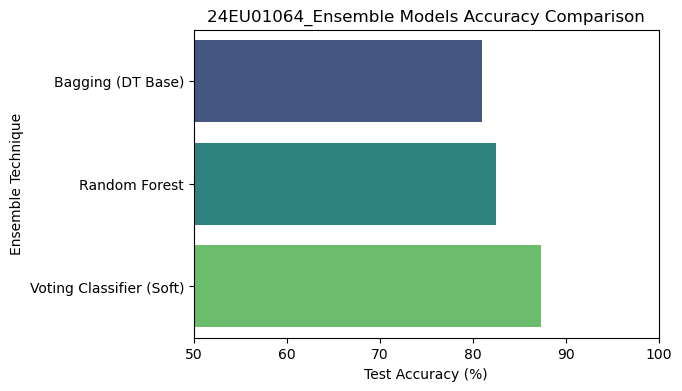

In [215]:
import matplotlib.pyplot as plt
import seaborn as sns
ensemble_results = pd.DataFrame({
    'Ensemble Technique': ['Bagging (DT Base)', 'Random Forest', 'Voting Classifier (Soft)'],
    'Test Accuracy (%)': [bagging_accuracy * 100, rf_accuracy * 100, voting_accuracy * 100]
})

print("--- Performance Comparison ---")
print(ensemble_results.to_string(index=False))

# Plot comparative bar chart
plt.figure(figsize=(6, 4))
sns.barplot(data=ensemble_results, x='Test Accuracy (%)', y='Ensemble Technique', palette='viridis')
plt.xlim([50, 100])
plt.title("24EU01064_Ensemble Models Accuracy Comparison")
plt.show()


In [216]:
#Task 3: Implement and compare boosting techniques including AdaBoost and Gradient Boosting for predictive enhancement

In [217]:
import warnings


In [218]:
warnings.filterwarnings("ignore")


In [219]:
from sklearn.ensemble import AdaBoostClassifier


In [220]:
from sklearn.metrics import accuracy_score


In [221]:
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)
adaboost_model.fit(X_train_s, y_train_s)

AdaBoostClassifier(random_state=42)

In [222]:
ada_preds = adaboost_model.predict(X_test_s)
ada_accuracy = accuracy_score(y_test_s, ada_preds)

In [223]:
print(f"AdaBoost Classifier Test Accuracy: {ada_accuracy * 100:.2f}%")


AdaBoost Classifier Test Accuracy: 82.54%


In [224]:
from sklearn.ensemble import GradientBoostingClassifier


In [225]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_s, y_train_s)

GradientBoostingClassifier(random_state=42)

In [226]:
gb_preds = gb_model.predict(X_test_s)
gb_accuracy = accuracy_score(y_test_s, gb_preds)


In [227]:
print(f"Gradient Boosting Classifier Test Accuracy: {gb_accuracy * 100:.2f}%")


Gradient Boosting Classifier Test Accuracy: 79.37%


In [228]:
from sklearn.model_selection import GridSearchCV


In [229]:
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5]
}

In [230]:
grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
grid_gb.fit(X_train_s, y_train_s)


GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy')

In [231]:
best_gb = grid_gb.best_estimator_
tuned_gb_preds = best_gb.predict(X_test_s)
tuned_gb_accuracy = accuracy_score(y_test_s, tuned_gb_preds)

In [232]:
print("Optimal Hyperparameters Selected:", grid_search_params := grid_gb.best_params_)


Optimal Hyperparameters Selected: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}


In [233]:
print(f"Tuned Gradient Boosting Test Accuracy: {tuned_gb_accuracy * 100:.2f}%")


Tuned Gradient Boosting Test Accuracy: 74.60%


In [234]:
master_comparison = pd.DataFrame({
    'Model Classifier': [
        'Bagging Classifier', 
        'Random Forest Classifier', 
        'Voting Ensemble (Soft)', 
        'AdaBoost Classifier', 
        'Base Gradient Boosting', 
        'Tuned Gradient Boosting'
    ],
    'Accuracy (%)': [
        bagging_accuracy * 100, 
        rf_accuracy * 100, 
        voting_accuracy * 100, 
        ada_accuracy * 100, 
        gb_accuracy * 100, 
        tuned_gb_accuracy * 100
    ]
}).sort_values(by='Accuracy (%)', ascending=False)

In [235]:
print("--- Master Performance Table: Tasks 2 & 3 ---")


--- Master Performance Table: Tasks 2 & 3 ---


In [236]:
print(master_comparison.to_string(index=False))


        Model Classifier  Accuracy (%)
  Voting Ensemble (Soft)     87.301587
Random Forest Classifier     82.539683
     AdaBoost Classifier     82.539683
      Bagging Classifier     80.952381
  Base Gradient Boosting     79.365079
 Tuned Gradient Boosting     74.603175


In [237]:
import matplotlib.pyplot as plt


In [238]:
import numpy as np


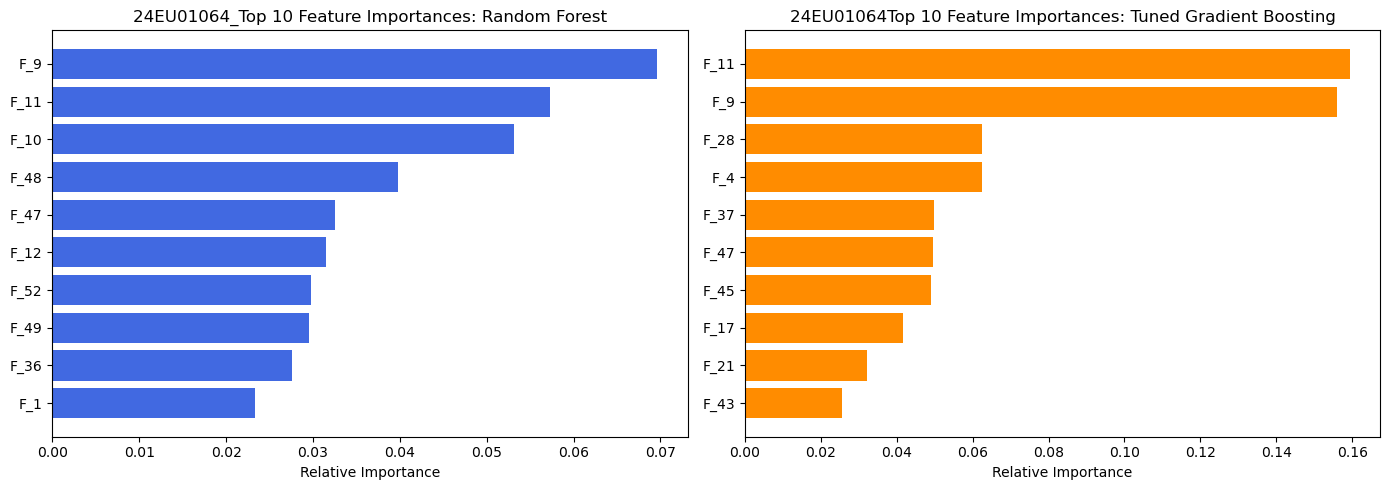

In [239]:
rf_importances = rf_model.feature_importances_
gb_importances = best_gb.feature_importances_

# Isolate top 10 features for both models
top_indices_rf = np.argsort(rf_importances)[-10:]
top_indices_gb = np.argsort(gb_importances)[-10:]

# Define the standard 60-feature names list cleanly
features_list = [f"F_{i}" for i in range(1, 61)]

# Set up canvas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Random Forest Importances
axes[0].barh(range(10), rf_importances[top_indices_rf], color='royalblue', align='center')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([features_list[i] for i in top_indices_rf])
axes[0].set_title("24EU01064_Top 10 Feature Importances: Random Forest")
axes[0].set_xlabel("Relative Importance")

# Plot Tuned Gradient Boosting Importances
axes[1].barh(range(10), gb_importances[top_indices_gb], color='darkorange', align='center')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([features_list[i] for i in top_indices_gb])
axes[1].set_title("24EU01064Top 10 Feature Importances: Tuned Gradient Boosting")
axes[1].set_xlabel("Relative Importance")

plt.tight_layout()
plt.show()